In [129]:
from sklearn.svm import SVC
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing
from sklearn import svm

In [130]:
raw_data=pd.read_excel("main_data - weighted.xlsx")
raw_data.head(5)

,EWO No,Responsiveness,Co_operativeness,Packaging,Order Date,Consistency,Item Name,On time Delivery,Delivery Performance,Fineness,...,Total Qty in (Kg),Total Price,Lead Time,Unit price,Quality,Cost,Time,Delivery,Reliability,Total
0,22 19 01 000001,5,4,3,43461,4,Jute Yarn,1,4,3,...,10.343222,25.0997,0,2.426681,1.29208,0.252024,0.000000,0.199345,0.185851,1.92930
1,22 19 01 000001,5,4,3,43461,4,Jute Yarn,1,4,3,...,41.561100,100.7772,0,2.424796,1.29208,0.252024,0.000000,0.199345,0.185851,1.92930
2,22 19 01 000002,3,1,3,43466,4,Jute Yarn,1,4,3,...,81.647464,153.0000,4,1.873910,1.16054,0.252024,0.165074,0.418482,0.114020,2.11014
3,22 19 01 000002,3,1,3,43466,4,Jute Yarn,1,4,3,...,10.026309,18.7884,4,1.873910,1.16054,0.252024,0.165074,0.418482,0.114020,2.11014
4,22 19 01 000002,3,1,3,43466,4,Jute Yarn,1,4,3,...,12.181802,22.8276,4,1.873910,1.16054,0.252024,0.165074,0.418482,0.114020,2.11014


In [131]:
frequency_table = raw_data["Vendor"].value_counts()
frequency_df = pd.DataFrame(frequency_table).reset_index()

# Rename the columns for clarity
frequency_df.columns = ['Vendor', 'Frequency']

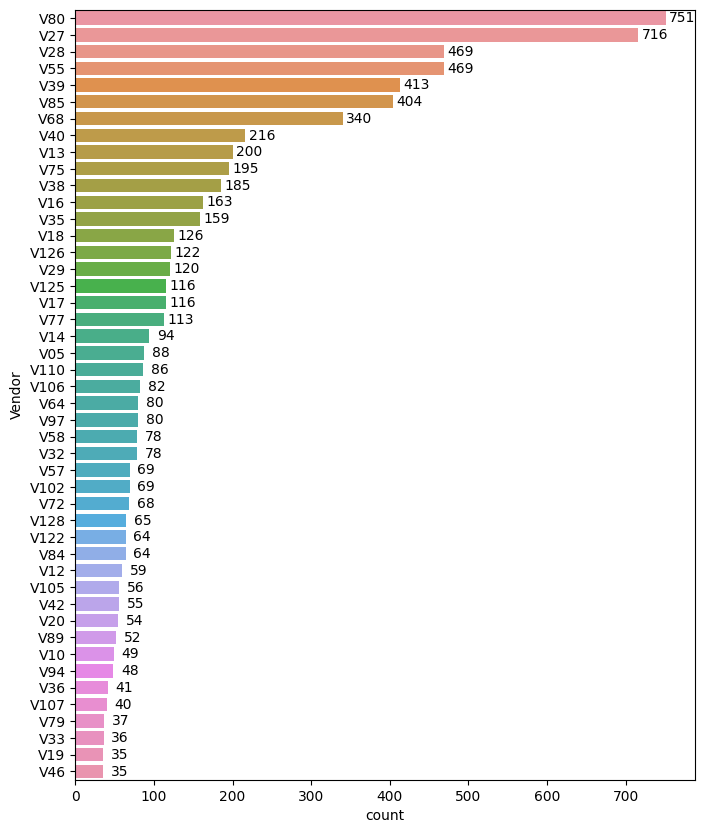

In [132]:
vendors_with_min_frequency = frequency_table[frequency_table >= 35].index.tolist()
filtered_data = raw_data[raw_data["Vendor"].isin(vendors_with_min_frequency)]
plt.figure(figsize=(8, 10))

# Create the countplot with bars sorted in descending order
ax = sns.countplot(y=filtered_data["Vendor"], order=filtered_data["Vendor"].value_counts().index)

# Annotate each bar with its exact value
for p in ax.patches:
    ax.annotate(format(p.get_width(), '.0f'), 
                 (p.get_width(), p.get_y() + p.get_height() / 2.), 
                 ha = 'center', va = 'center', 
                 xytext = (12, 0), 
                 textcoords = 'offset points')

plt.show()

In [133]:
outliers=[]
def detect_outlier(data_1):
    outliers=[]
    threshold=3
    mean_1 = np.mean(data_1)
    std_1 =np.std(data_1)
    
    
    for y in data_1:
        z_score= (y - mean_1)/std_1 
        if np.abs(z_score) > threshold:
            outliers.append(y)
    return outliers

In [134]:
value = set(filtered_data['Vendor'])
for i in value:
    print(i)
    filtered_data_2=filtered_data[filtered_data['Vendor'] == i]
    dataset=filtered_data_2['Length(cm)']
    outlier_datapoints = detect_outlier(dataset)
    for j in outlier_datapoints:
        filtered_data_2 = filtered_data[(filtered_data['Vendor'] == i) & (filtered_data['Length(cm)'] == j)]
        filtered_data.drop(filtered_data_2.index, inplace=True)

V46
V89
V77
V17
V14
V84
V05
V126
V13
V110
V33
V105
V64
V12
V38
V102
V68
V75
V128
V72
V122
V80
V29
V35
V79
V16
V28
V107
V55
V85
V125
V20
V97
V36
V42
V58
V19
V57
V39
V40
V106
V18
V32
V94
V27


C:\Users\Proven\AppData\Local\Temp\ipykernel_6472\4050813565.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.drop(filtered_data_2.index, inplace=True)


V10


In [135]:

value = set(filtered_data['Vendor'])
for i in value:
    print(i)
    filtered_data_2=filtered_data[filtered_data['Vendor'] == i]
    dataset=filtered_data_2['Strength (gm/denier)']
    outlier_datapoints = detect_outlier(dataset)
    for j in outlier_datapoints:
        filtered_data_2 = filtered_data[(filtered_data['Vendor'] == i) & (filtered_data['Strength (gm/denier)'] == j)]
        filtered_data.drop(filtered_data_2.index, inplace=True)


V46
V89
V77
V17
V14
V84
V05
V126
V13
V110
V33
V105
V64
V12
V38
V102
V68
V75
V128
V72
V122
V80
V29
V35
V79
V16
V28


C:\Users\Proven\AppData\Local\Temp\ipykernel_6472\350193913.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.drop(filtered_data_2.index, inplace=True)


V107
V55
V85
V125
V20
V97
V36
V42
V58
V19
V57
V39
V40
V106
V18
V32
V94
V27
V10


C:\Users\Proven\AppData\Local\Temp\ipykernel_6472\1540775322.py:10: RuntimeWarning: invalid value encountered in scalar divide
  z_score= (y - mean_1)/std_1


In [136]:

for i in value:
    print(i)
    filtered_data_2=filtered_data[filtered_data['Vendor'] == i]
    dataset=filtered_data_2['Unit price']
    outlier_datapoints = detect_outlier(dataset)
    for j in outlier_datapoints:
        filtered_data_2 = filtered_data[(filtered_data['Vendor'] == i) & (filtered_data['Unit price'] == j)]
        filtered_data.drop(filtered_data_2.index, inplace=True)


V46
V89
V77
V17
V14
V84
V05
V126
V13
V110
V33
V105
V64
V12
V38
V102
V68
V75
V128
V72
V122
V80
V29
V35
V79
V16
V28
V107
V55
V85
V125
V20


C:\Users\Proven\AppData\Local\Temp\ipykernel_6472\1693463254.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.drop(filtered_data_2.index, inplace=True)


V97
V36
V42
V58
V19
V57
V39
V40
V106
V18
V32
V94
V27
V10


In [137]:
len(filtered_data)
filtered_data.dropna(inplace=True)
len(filtered_data)

C:\Users\Proven\AppData\Local\Temp\ipykernel_6472\3518902970.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data.dropna(inplace=True)


6785

In [138]:
filtered_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Responsiveness,6785.0,4.370818,0.721860,3.000000,4.000000,5.000000,5.000000,5.000000
Co_operativeness,6785.0,3.503316,1.093787,1.000000,3.000000,4.000000,4.000000,5.000000
Packaging,6785.0,3.041857,0.317092,1.000000,3.000000,3.000000,3.000000,5.000000
Order Date,6785.0,43650.495357,111.414637,43461.000000,43556.000000,43640.000000,43757.000000,43830.000000
Consistency,6785.0,3.924982,0.424211,1.000000,4.000000,4.000000,4.000000,5.000000
On time Delivery,6785.0,0.957996,0.200614,0.000000,1.000000,1.000000,1.000000,1.000000
Delivery Performance,6785.0,3.703169,0.834312,1.000000,3.000000,4.000000,4.000000,5.000000
Fineness,6785.0,4.306116,1.038981,1.000000,3.000000,5.000000,5.000000,5.000000
Length(cm),6785.0,188.880158,51.627632,109.862205,146.023622,172.322835,227.254000,354.508000
Strength (gm/denier),6785.0,5.069158,0.312237,3.850000,4.900000,5.250000,5.250000,7.000000


In [140]:
filtered_data.to_excel("Clean_excell.xlsx")

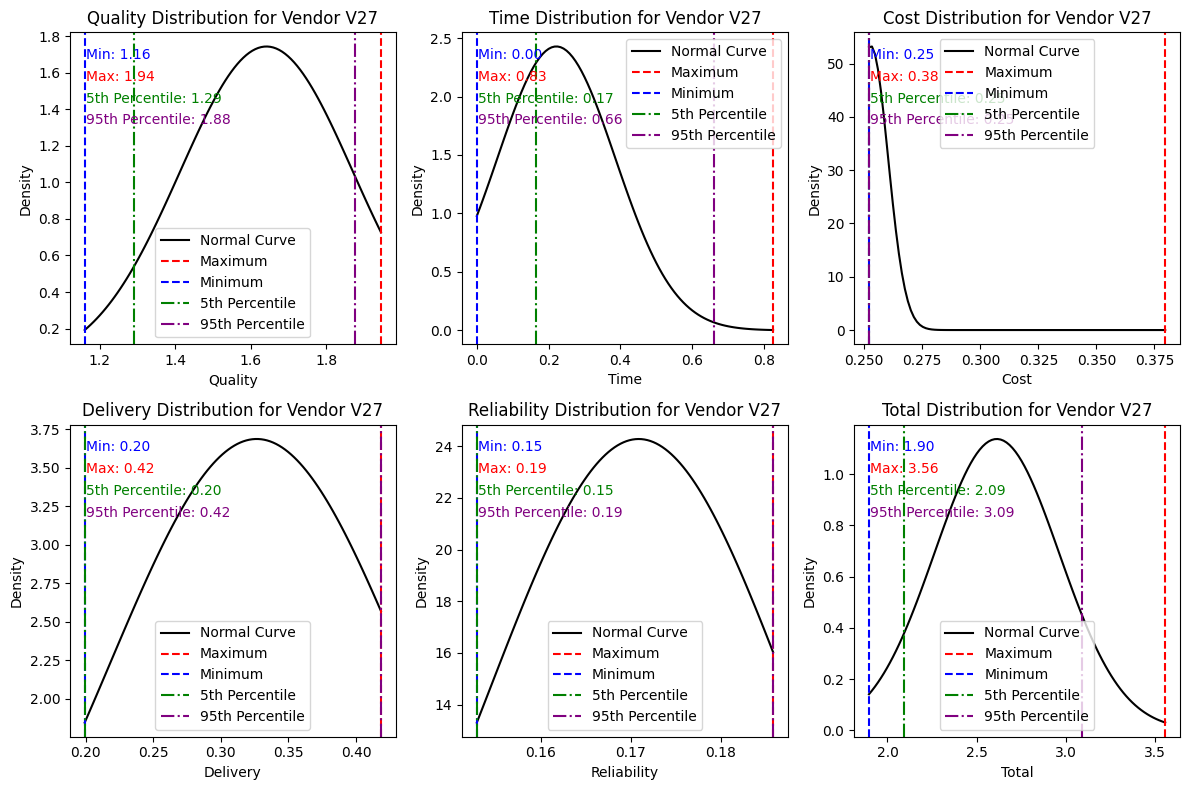

In [139]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Assuming raw_data is your DataFrame containing 'Vendor', 'Quality', 'Time', 'Cost', 'Delivery', 'Reliability', 'Total'

# Filter data for Vendor 'V27'
data_v27 = filtered_data[filtered_data['Vendor'] == 'V27']

# Extract columns of interest for Vendor 'V27'
columns_of_interest = ['Quality', 'Time', 'Cost', 'Delivery', 'Reliability', 'Total']

# Calculate maximum and minimum values for each column
max_values = data_v27[columns_of_interest].max()
min_values = data_v27[columns_of_interest].min()

# Calculate 5th and 95th percentiles for Vendor 'V27'
percentiles_5 = data_v27[columns_of_interest].quantile(0.05)
percentiles_95 = data_v27[columns_of_interest].quantile(0.95)

# Plotting each column separately
plt.figure(figsize=(12, 8))

for i, col in enumerate(columns_of_interest, start=1):
    plt.subplot(2, 3, i)
    
    # Plot normal distribution curve
    mean = data_v27[col].mean()
    std_dev = data_v27[col].std()
    x = np.linspace(data_v27[col].min(), data_v27[col].max(), 100)
    plt.plot(x, norm.pdf(x, mean, std_dev), label='Normal Curve', color='black')
    
    # Plot vertical lines for maximum and minimum values
    plt.axvline(max_values[col], color='red', linestyle='--', label='Maximum')
    plt.axvline(min_values[col], color='blue', linestyle='--', label='Minimum')
    
    # Plot vertical lines for 5th and 95th percentiles
    plt.axvline(percentiles_5[col], color='green', linestyle='-.', label='5th Percentile')
    plt.axvline(percentiles_95[col], color='purple', linestyle='-.', label='95th Percentile')
    
    # Add annotations for values
    plt.text(0.05, 0.95, f"Min: {min_values[col]:.2f}", transform=plt.gca().transAxes, va='top', ha='left', color='blue')
    plt.text(0.05, 0.88, f"Max: {max_values[col]:.2f}", transform=plt.gca().transAxes, va='top', ha='left', color='red')
    plt.text(0.05, 0.81, f"5th Percentile: {percentiles_5[col]:.2f}", transform=plt.gca().transAxes, va='top', ha='left', color='green')
    plt.text(0.05, 0.74, f"95th Percentile: {percentiles_95[col]:.2f}", transform=plt.gca().transAxes, va='top', ha='left', color='purple')
    
    # Add labels and title
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.title(f'{col} Distribution for Vendor V27')
    
    # Add legend
    plt.legend()

plt.tight_layout()
plt.show()


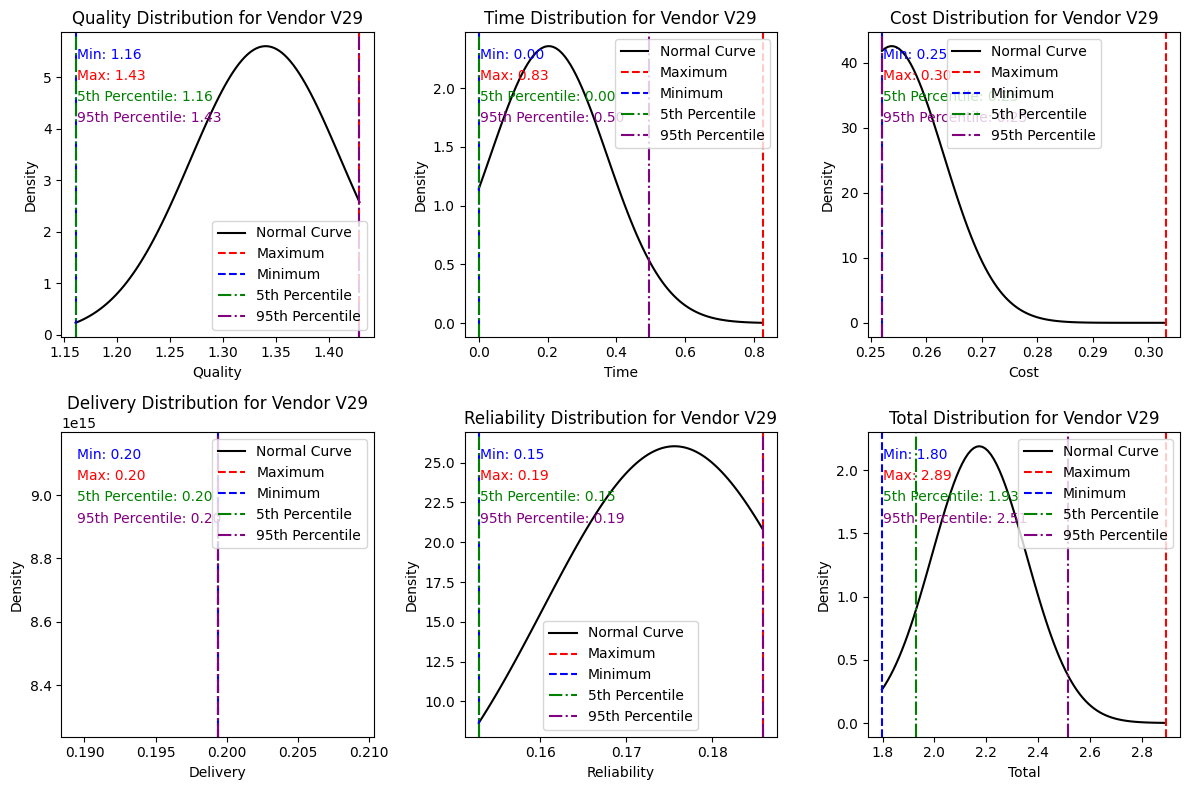

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

# Assuming raw_data is your DataFrame containing 'Vendor', 'Quality', 'Time', 'Cost', 'Delivery', 'Reliability', 'Total'

# Filter data for Vendor 'V29'
data_v29 = filtered_data[filtered_data['Vendor'] == 'V29']

# Extract columns of interest for Vendor 'V29'
columns_of_interest = ['Quality', 'Time', 'Cost', 'Delivery', 'Reliability', 'Total']

# Calculate maximum and minimum values for each column
max_values_v29 = data_v29[columns_of_interest].max()
min_values_v29 = data_v29[columns_of_interest].min()

# Calculate 5th and 95th percentiles for Vendor 'V29'
percentiles_5_v29 = data_v29[columns_of_interest].quantile(0.05)
percentiles_95_v29 = data_v29[columns_of_interest].quantile(0.95)

# Plotting each column separately
plt.figure(figsize=(12, 8))

for i, col in enumerate(columns_of_interest, start=1):
    plt.subplot(2, 3, i)
    
    # Plot normal distribution curve
    mean_v29 = data_v29[col].mean()
    std_dev_v29 = data_v29[col].std()
    x_v29 = np.linspace(data_v29[col].min(), data_v29[col].max(), 100)
    plt.plot(x_v29, norm.pdf(x_v29, mean_v29, std_dev_v29), label='Normal Curve', color='black')
    
    # Plot vertical lines for maximum and minimum values
    plt.axvline(max_values_v29[col], color='red', linestyle='--', label='Maximum')
    plt.axvline(min_values_v29[col], color='blue', linestyle='--', label='Minimum')
    
    # Plot vertical lines for 5th and 95th percentiles
    plt.axvline(percentiles_5_v29[col], color='green', linestyle='-.', label='5th Percentile')
    plt.axvline(percentiles_95_v29[col], color='purple', linestyle='-.', label='95th Percentile')
    
    # Add annotations for values
    plt.text(0.05, 0.95, f"Min: {min_values_v29[col]:.2f}", transform=plt.gca().transAxes, va='top', ha='left', color='blue')
    plt.text(0.05, 0.88, f"Max: {max_values_v29[col]:.2f}", transform=plt.gca().transAxes, va='top', ha='left', color='red')
    plt.text(0.05, 0.81, f"5th Percentile: {percentiles_5_v29[col]:.2f}", transform=plt.gca().transAxes, va='top', ha='left', color='green')
    plt.text(0.05, 0.74, f"95th Percentile: {percentiles_95_v29[col]:.2f}", transform=plt.gca().transAxes, va='top', ha='left', color='purple')
    
    # Add labels and title
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.title(f'{col} Distribution for Vendor V29')
    
    # Add legend
    plt.legend()

plt.tight_layout()
plt.show()


In [77]:
import pandas as pd

# Assuming your dataset is stored in a DataFrame called raw_data

# Define a function to apply the condition
def assign_QV27(quality_value):
    if quality_value > 1.88:
        return 3
    elif quality_value > 1.43 and quality_value <= 1.88:
        return 2
    elif quality_value<=1.43 and quality_value>1.16:
        return 1
    else:
        return 0

# Apply the function to create the new column 'QV27'
filtered_data['QV27'] = filtered_data['Quality'].apply(lambda x: assign_QV27(x))

# Display the updated DataFrame to verify
print(raw_data.head())


            EWO No  Responsiveness  Co_operativeness  Packaging  Order Date  \
0  22 19 01 000001               5                 4          3       43461   
1  22 19 01 000001               5                 4          3       43461   
2  22 19 01 000002               3                 1          3       43466   
3  22 19 01 000002               3                 1          3       43466   
4  22 19 01 000002               3                 1          3       43466   

   Consistency  Item Name  On time Delivery  Delivery Performance  Fineness  \
0            4  Jute Yarn                 1                     4         3   
1            4  Jute Yarn                 1                     4         3   
2            4  Jute Yarn                 1                     4         3   
3            4  Jute Yarn                 1                     4         3   
4            4  Jute Yarn                 1                     4         3   

   ...  Total Price  Lead Time  Unit price  Qualit

C:\Users\Proven\AppData\Local\Temp\ipykernel_6472\2436841740.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['QV27'] = filtered_data['Quality'].apply(lambda x: assign_QV27(x))


In [78]:
import pandas as pd

# Assuming your dataset is stored in a DataFrame called raw_data

# Define a function to apply the condition
def assign_TV27(time):
    if time > 0.66:
        return 3
    elif time > 0.50 and time <= 0.66:
        return 2
    elif time<=0.50 and time>0.17:
        return 1
    else:
        return 0

# Apply the function to create the new column 'QV27'
filtered_data['TV27'] = filtered_data['Time'].apply(lambda x: assign_TV27(x))

# Display the updated DataFrame to verify
print(filtered_data.head())


             EWO No  Responsiveness  Co_operativeness  Packaging  Order Date  \
0   22 19 01 000001               5                 4          3       43461   
1   22 19 01 000001               5                 4          3       43461   
11  22 19 01 000004               4                 3          3       43466   
12  22 19 01 000005               4                 3          3       43466   
13  22 19 01 000005               4                 3          3       43466   

    Consistency  Item Name  On time Delivery  Delivery Performance  Fineness  \
0             4  Jute Yarn                 1                     4         3   
1             4  Jute Yarn                 1                     4         3   
11            4  Jute Yarn                 1                     4         3   
12            4  Jute Yarn                 1                     4         3   
13            4  Jute Yarn                 1                     4         3   

    ...  Unit price  Quality      Cost

C:\Users\Proven\AppData\Local\Temp\ipykernel_6472\275964772.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['TV27'] = filtered_data['Time'].apply(lambda x: assign_TV27(x))


In [79]:
import pandas as pd

# Assuming your dataset is stored in a DataFrame called raw_data

# Define a function to apply the condition
def assign_DV27(delivery):
    if delivery > 0.42:
        return 3
    elif delivery > 0.20 and delivery =< 0.42:
        return 2
    elif delivery==0.20:
        return 1
    else:
        return 0

# Apply the function to create the new column 'QV27'
filtered_data['DV27'] = filtered_data['Delivery'].apply(lambda x: assign_TV27(x))

# Display the updated DataFrame to verify
print(filtered_data.head())


             EWO No  Responsiveness  Co_operativeness  Packaging  Order Date  \
0   22 19 01 000001               5                 4          3       43461   
1   22 19 01 000001               5                 4          3       43461   
11  22 19 01 000004               4                 3          3       43466   
12  22 19 01 000005               4                 3          3       43466   
13  22 19 01 000005               4                 3          3       43466   

    Consistency  Item Name  On time Delivery  Delivery Performance  Fineness  \
0             4  Jute Yarn                 1                     4         3   
1             4  Jute Yarn                 1                     4         3   
11            4  Jute Yarn                 1                     4         3   
12            4  Jute Yarn                 1                     4         3   
13            4  Jute Yarn                 1                     4         3   

    ...  Unit price  Quality      Cost

C:\Users\Proven\AppData\Local\Temp\ipykernel_6472\1247571283.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['DV27'] = filtered_data['Delivery'].apply(lambda x: assign_TV27(x))


In [97]:
import pandas as pd

# Assuming your dataset is stored in a DataFrame called raw_data

# Define a function to apply the condition
def assign_RV27(time):
    if time > 0.50:
        return 3
    elif time > 0.19 and time <= 0.50:
        return 2
    elif time>0.15 and time<=0.19:
        return 1
    else:
        return 0

# Apply the function to create the new column 'QV27'
filtered_data['RV27'] = filtered_data['Reliability'].apply(lambda x: assign_TV27(x))

# Display the updated DataFrame to verify
print(filtered_data.head())


             EWO No  Responsiveness  Co_operativeness  Packaging  Order Date  \
0   22 19 01 000001               5                 4          3       43461   
1   22 19 01 000001               5                 4          3       43461   
11  22 19 01 000004               4                 3          3       43466   
12  22 19 01 000005               4                 3          3       43466   
13  22 19 01 000005               4                 3          3       43466   

    Consistency  Item Name  On time Delivery  Delivery Performance  Fineness  \
0             4  Jute Yarn                 1                     4         3   
1             4  Jute Yarn                 1                     4         3   
11            4  Jute Yarn                 1                     4         3   
12            4  Jute Yarn                 1                     4         3   
13            4  Jute Yarn                 1                     4         3   

    ...  Quality      Cost      Time  

C:\Users\Proven\AppData\Local\Temp\ipykernel_6472\1846122009.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['RV27'] = filtered_data['Reliability'].apply(lambda x: assign_TV27(x))


In [101]:
import pandas as pd

# Assuming your dataset is stored in a DataFrame called raw_data

# Define a function to apply the condition
def assign_ToV27(time):
    if time > 3.09:
        return 4
    elif time > 2.51 and time <= 3.09:
        return 3
    elif time>2.09 and time<=2.51:
        return 2
    elif time>1.93 and time<=2.09: 
        return 1
    else:
        return 0

# Apply the function to create the new column 'QV27'
filtered_data['ToV27'] = filtered_data['Total'].apply(lambda x: assign_TV27(x))

# Display the updated DataFrame to verify
print(filtered_data.head())


             EWO No  Responsiveness  Co_operativeness  Packaging  Order Date  \
0   22 19 01 000001               5                 4          3       43461   
1   22 19 01 000001               5                 4          3       43461   
11  22 19 01 000004               4                 3          3       43466   
12  22 19 01 000005               4                 3          3       43466   
13  22 19 01 000005               4                 3          3       43466   

    Consistency  Item Name  On time Delivery  Delivery Performance  Fineness  \
0             4  Jute Yarn                 1                     4         3   
1             4  Jute Yarn                 1                     4         3   
11            4  Jute Yarn                 1                     4         3   
12            4  Jute Yarn                 1                     4         3   
13            4  Jute Yarn                 1                     4         3   

    ...      Cost      Time  Delivery 

C:\Users\Proven\AppData\Local\Temp\ipykernel_6472\2285515401.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['ToV27'] = filtered_data['Total'].apply(lambda x: assign_TV27(x))


C:\Users\Proven\AppData\Local\Temp\ipykernel_6472\889654783.py:3: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corrmat = m_filtered_data.corr()


<Axes: >

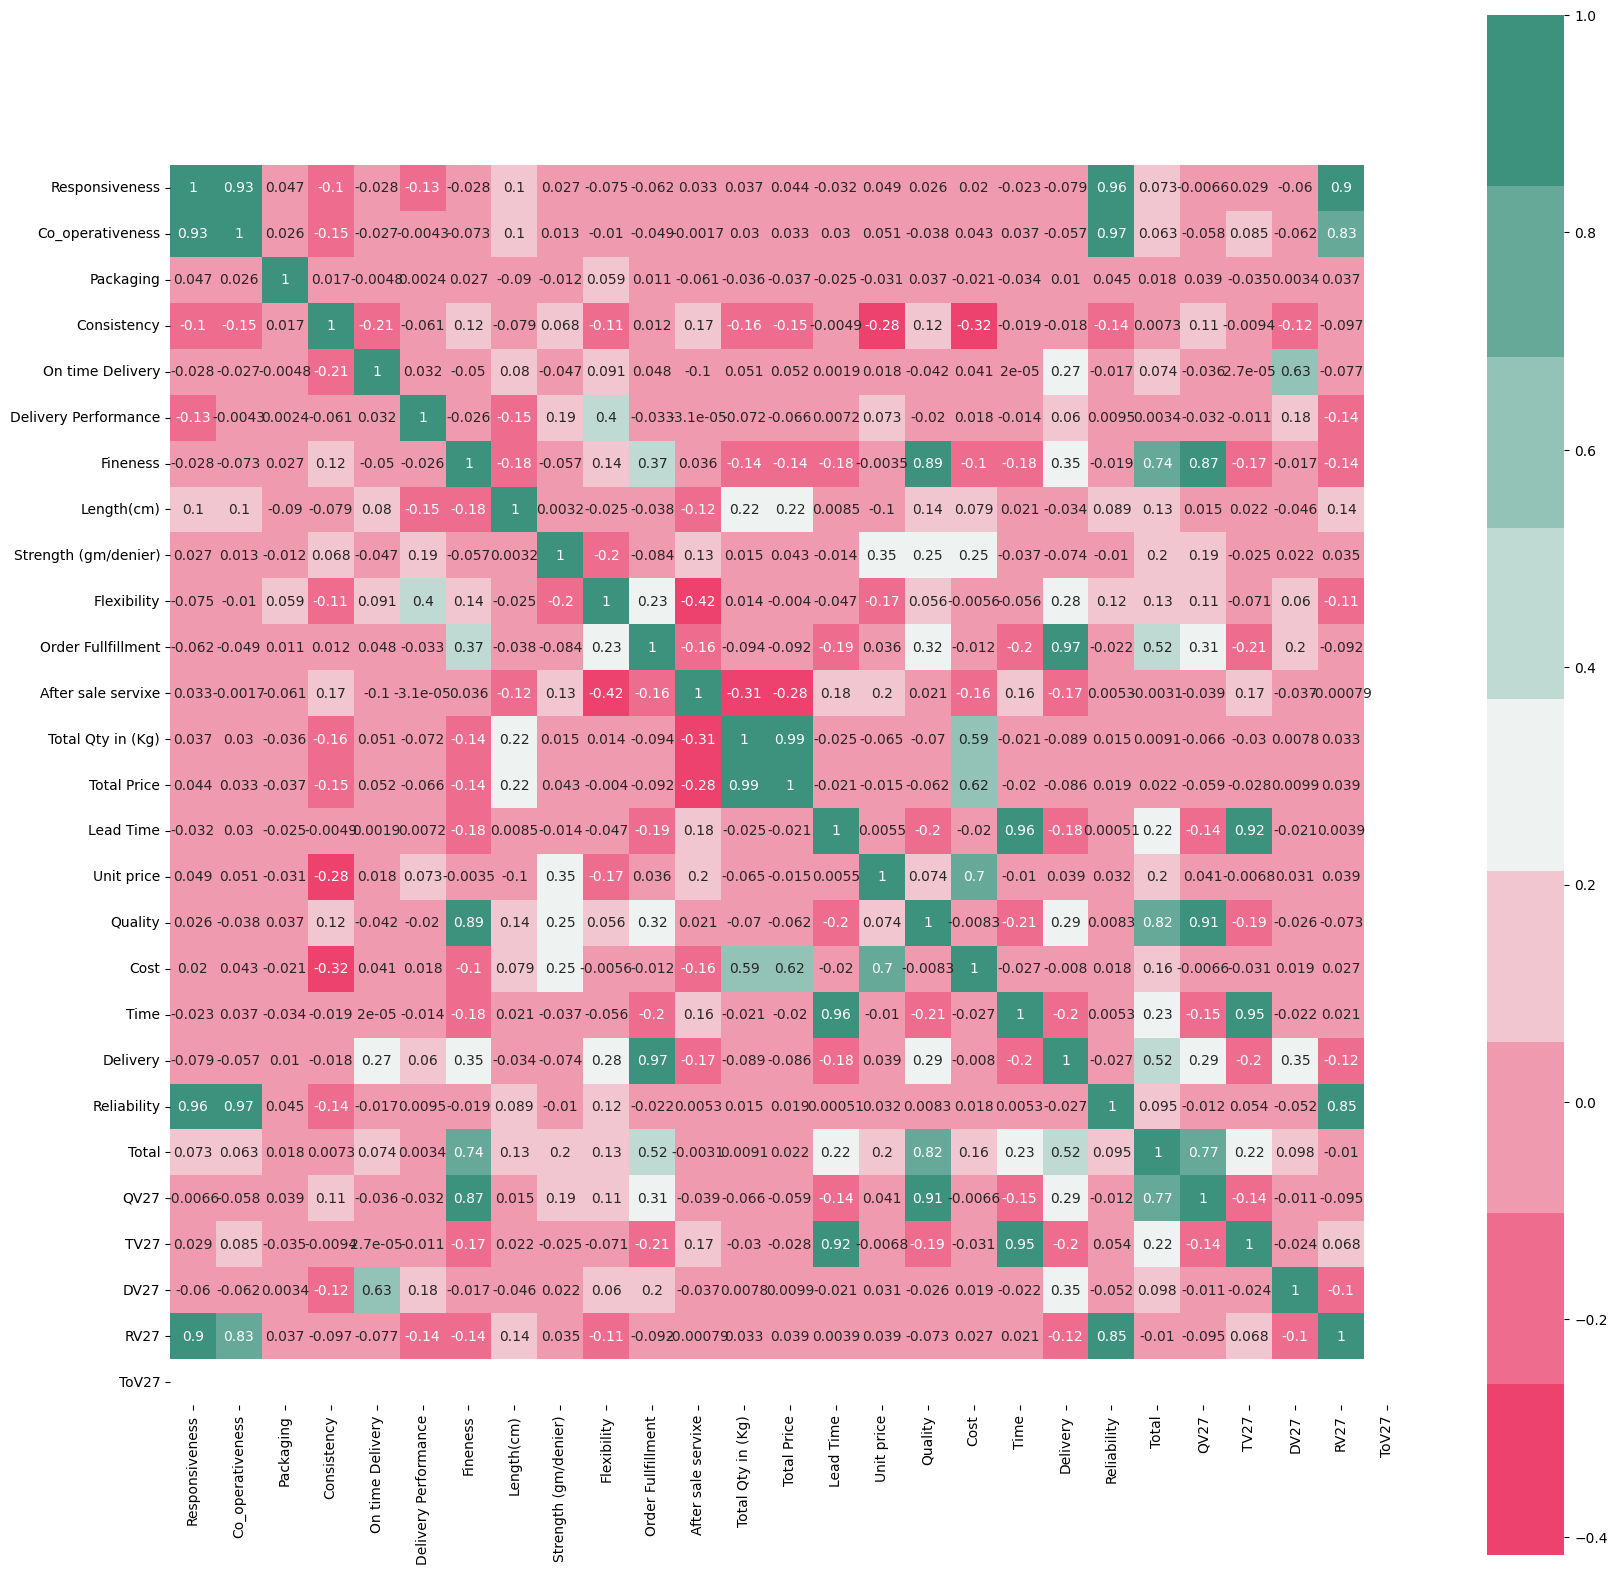

In [102]:
cmap = sns.diverging_palette(2, 165, s=80, l=55, n=9)
m_filtered_data=filtered_data.drop(columns=['Item Name', 'EWO No', 'Order Date','Delivery Date','Supplier Address'])
corrmat = m_filtered_data.corr()
plt.subplots(figsize=(20,20))
sns.heatmap(corrmat,cmap= cmap,annot=True, square=True)

In [125]:
X=m_filtered_data.drop(columns=['Vendor','Quality','Cost','Time','Delivery','Reliability','Total','RV27','ToV27'])
y=m_filtered_data['Vendor']
y = y.str.replace('V', '')
y = y.astype(int)

In [126]:
col_names = list(X.columns)
s_scaler = preprocessing.StandardScaler()
X_scaled= s_scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=col_names)   
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
Responsiveness,6785.0,5.864465e-16,1.000074,-1.899147,-0.513736,0.871676,0.871676,0.871676
Co_operativeness,6785.0,-2.513342e-17,1.000074,-2.288837,-0.460193,0.454129,0.454129,1.368451
Packaging,6785.0,6.367133e-16,1.000074,-6.439798,-0.132013,-0.132013,-0.132013,6.175772
Consistency,6785.0,2.262008e-16,1.000074,-6.895615,0.176855,0.176855,0.176855,2.534345
On time Delivery,6785.0,-1.926896e-16,1.000074,-4.775669,0.209395,0.209395,0.209395,0.209395
Delivery Performance,6785.0,8.377807e-17,1.000074,-3.240237,-0.842875,0.355806,0.355806,1.554487
Fineness,6785.0,-2.094452e-16,1.000074,-3.182312,-1.257206,0.667900,0.667900,0.667900
Length(cm),6785.0,-4.691572e-16,1.000074,-1.530649,-0.830170,-0.320730,0.743336,3.208360
Strength (gm/denier),6785.0,-1.843117e-16,1.000074,-3.904886,-0.541803,0.579225,0.579225,6.184364
Flexibility,6785.0,8.377807e-18,1.000074,-2.033160,-0.884439,0.264282,1.413003,1.413003


In [127]:
X_train, X_test, y_train,y_test = train_test_split(X_scaled,y,test_size=0.25,random_state=25)

In [128]:
# Instantiating the Random Forest Classifier
model2 = RandomForestClassifier(n_estimators=100, random_state=42)  # You can adjust parameters like n_estimators, max_depth, etc.

# Fitting the model
model2.fit(X_train, y_train)
y_pred = model2.predict(X_test)

# Get the score
score = model2.score(X_test, y_test)
print(f"Model Score: {score}")

Model Score: 0.9575721862109605


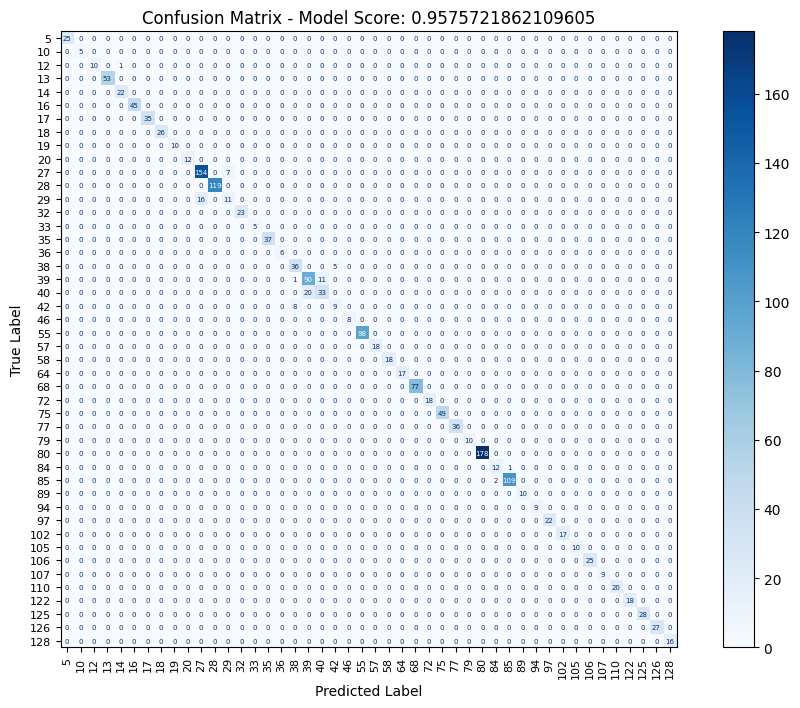

In [116]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming you already have the predictions (y_pred) and the true labels (y_test)

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get the unique labels from the true labels
labels = sorted(y_test.unique())

# Set a larger figure size
fig, ax = plt.subplots(figsize=(12, 8))

# Display the confusion matrix with actual class labels
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', ax=ax, values_format='d')

# Adjust font sizes for the labels and title
ax.set_title(f"Confusion Matrix - Model Score: {score}", fontsize=12)
ax.set_xlabel('Predicted Label', fontsize=10)
ax.set_ylabel('True Label', fontsize=10)
ax.tick_params(axis='both', which='major', labelsize=8)

# Rotate x-axis labels vertically
plt.xticks(rotation=90)

# Adjust font sizes for the internal text
for text in ax.texts:
    text.set_fontsize(5)

plt.show()
